In [ ]:
"""This code loads the Iris dataset, preprocesses the data, trains a Naive Bayes model to classify the iris species, evaluates the model with confusion matrix and classification metrics, and visualizes the results."""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score, 
                           classification_report,
                           precision_score,
                           recall_score)


In [2]:
iris = load_iris()
print("Iris dataset keys:")
print(iris.keys())

Iris dataset keys:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
X = pd.DataFrame(iris['data'], columns=iris['feature_names'])
y = pd.DataFrame(iris['target'], columns=['target'])
target_names = pd.DataFrame(iris['target_names'], columns=['target_names'])

In [4]:
print("\nTarget names:")
print(target_names.head())


Target names:
  target_names
0       setosa
1   versicolor
2    virginica


In [5]:
print("\nFeature data head:")
print(X.head())


Feature data head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [6]:
print("\nData shapes:")
print(X.shape, y.shape)


Data shapes:
(150, 4) (150, 1)


In [7]:
print("\nFeature info:")
print(X.info())


Feature info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [8]:
print("\nTarget info:")
print(y.info())


Target info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


In [9]:
print("\nFeature statistics:")
print(X.describe())


Feature statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(X.values)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y.values, test_size=0.2, random_state=42)
print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Train/test shapes:
(120, 4) (30, 4) (120, 1) (30, 1)


In [12]:
model = GaussianNB()
model.fit(X_train, y_train)

C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [13]:
y_pred = model.predict(X_test)

In [14]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


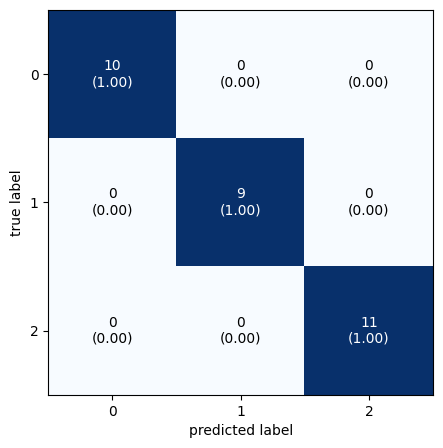

In [15]:
plot_confusion_matrix(conf_mat=cm, figsize=(5,5), show_normed=True)
plt.show()

In [16]:
print(f"\nTP value is {cm[0,0]}")
print(f"TN value is {cm[1,1] + cm[2,2]}")
print(f"FP value is {cm[0,1] + cm[0,2]}")
print(f"FN value is {cm[1,0] + cm[2,0]}")


TP value is 10
TN value is 20
FP value is 0
FN value is 0


In [17]:
print(f"\nAccuracy score is {accuracy_score(y_test, y_pred)}")
print(f"Error rate is {1 - accuracy_score(y_test, y_pred)}")
print(f"Precision score is {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall score is {recall_score(y_test, y_pred, average='macro')}")


Accuracy score is 1.0
Error rate is 0.0
Precision score is 1.0
Recall score is 1.0


In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
"""2.1 Importing Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score, 
                           classification_report,
                           precision_score,
                           recall_score)
pandas: Used for handling and manipulating data in DataFrame format.

numpy: Provides support for numerical operations.

matplotlib.pyplot and seaborn: Used for data visualization.

load_iris: Loads the Iris dataset.

StandardScaler: Standardizes the feature data by scaling it to zero mean and unit variance.

train_test_split: Splits the dataset into training and testing sets.

GaussianNB: A Naive Bayes classifier based on the Gaussian distribution.

plot_confusion_matrix: Plots the confusion matrix for model evaluation.

confusion_matrix, accuracy_score, classification_report, precision_score, recall_score: Evaluation metrics to assess the model's performance.

2.2 Loading and Exploring the Iris Dataset


iris = load_iris()
print("Iris dataset keys:")
print(iris.keys())
Loads the Iris dataset from sklearn and prints the keys of the dataset. The keys are:

data: Feature values.

target: The target labels (species).

target_names: Names of the target classes.

feature_names: Names of the feature columns.



X = pd.DataFrame(iris['data'], columns=iris['feature_names'])
y = pd.DataFrame(iris['target'], columns=['target'])
target_names = pd.DataFrame(iris['target_names'], columns=['target_names'])
print("\nTarget names:")
print(target_names.head())
Converts the feature data (iris['data']) into a pandas DataFrame X with appropriate column names from iris['feature_names'].

Converts the target data (iris['target']) into a DataFrame y.

Creates a DataFrame target_names containing the target class names.

Prints the target names for each class.



print("\nFeature data head:")
print(X.head())
Displays the first five rows of the feature data to give a preview.


print("\nData shapes:")
print(X.shape, y.shape)
Prints the shapes of the feature data X and target data y.


print("\nFeature info:")
print(X.info())
Displays detailed information about the X DataFrame, such as the data types, non-null counts, and memory usage.


print("\nTarget info:")
print(y.info())
Displays information about the target DataFrame y.


print("\nFeature statistics:")
print(X.describe())
Prints summary statistics (count, mean, std, min, max, etc.) for the feature data.

2.3 Data Scaling

scaler = StandardScaler()
X = scaler.fit_transform(X.values)
Initializes the StandardScaler and applies it to scale the feature data (X) to have zero mean and unit variance.

This is a crucial step for many machine learning algorithms, especially for distance-based algorithms like Naive Bayes.

2.4 Splitting Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(X, y.values, test_size=0.2, random_state=42)
print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
Splits the data into training and testing sets using train_test_split().

test_size=0.2: 20% of the data will be used for testing, and 80% for training.

random_state=42: Ensures reproducibility of the data split.

Prints the shapes of the training and testing sets for both features (X_train, X_test) and target (y_train, y_test).

2.5 Training the Naive Bayes Model

model = GaussianNB()
model.fit(X_train, y_train)
Creates an instance of the GaussianNB model.

Fits the model on the training data (X_train, y_train).

2.6 Making Predictions and Evaluating the Model

y_pred = model.predict(X_test)
Makes predictions (y_pred) using the trained model on the testing data (X_test).


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
Computes the confusion matrix (cm) to evaluate the model's performance.


plot_confusion_matrix(conf_mat=cm, figsize=(5,5), show_normed=True)
plt.show()
Visualizes the confusion matrix using plot_confusion_matrix(). It helps to better understand the classification performance.


print(f"\nTP value is {cm[0,0]}")
print(f"TN value is {cm[1,1] + cm[2,2]}")
print(f"FP value is {cm[0,1] + cm[0,2]}")
print(f"FN value is {cm[1,0] + cm[2,0]}")
Extracts and prints individual values from the confusion matrix:

TP: True Positive.

TN: True Negative.

FP: False Positive.

FN: False Negative.

2.7 Model Evaluation Metrics

print(f"\nAccuracy score is {accuracy_score(y_test, y_pred)}")
print(f"Error rate is {1 - accuracy_score(y_test, y_pred)}")
print(f"Precision score is {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall score is {recall_score(y_test, y_pred, average='macro')}")
Prints various evaluation metrics:

Accuracy score: Proportion of correct predictions.

Error rate: 1 minus the accuracy.

Precision score: Proportion of true positives out of all predicted positives (average='macro' means unweighted average across all classes).

Recall score: Proportion of true positives out of all actual positives.


print("\nClassification Report:")
print(classification_report(y_test, y_pred))
Prints the classification report, which includes precision, recall, F1-score, and support for each class."""